1. sample from trained models and test pearson r with and without pre initializing nmf run 1
2. repeat this for each celltype combination to compute specificity (with rmsd against a diagonal matrix and using sinkhon_knopp from scipy)

## Setup environment

### Import modules

In [1]:
import functools
from pathlib import Path
import itertools
from tqdm import tqdm
from typing import Literal, Union

import scvi
import scanpy as sc
import numpy as np
import pandas as pd
from sklearn.decomposition import non_negative_factorization
from anndata import AnnData
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

/home/gruengroup/christian/mamba_envs/scvi_cuda-env/lib/python3.10/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_categorical_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/home/gruengroup/christian/mamba_envs/scvi_cuda-env/lib/python3.10/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_continuous_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


### Utils

In [2]:
def cosine_similarity_rows(A: np.array, B: np.array) -> np.array:
    norms_A = np.linalg.norm(A, axis=1)
    norms_B = np.linalg.norm(B, axis=1)
    dot_products = np.einsum('ij,ij->i', A, B)
    return dot_products / (norms_A * norms_B)

def non_negative_factorization_reimplementation(
        X: np.ndarray, 
        W: np.ndarray | None = None, 
        H: None | np.ndarray=None, 
        n_components: Union[None, int]=None, 
        init: Literal["custom"] | None=None,
        update_H: bool=True,
        max_iter: int=200
) -> tuple[np.ndarray, np.ndarray, int]:
    if n_components is None:
        if H is not None:
            n_components = H.shape[0]
        else:
            n_components = min(X.shape)
    if W is None and init != "custom":
        W = np.ones((X.shape[0], n_components))
    if H is None and init != "custom":
        H = np.ones((n_components, X.shape[1]))
    
    for _ in tqdm(range(max_iter)):
        W = (W.T * (H @ X.T) / (H @ H.T @ W.T + 1e-9)).T
        if update_H:
            H = (H * (W.T @ X) / (W.T @ W @ H + 1e-9))
    return W, H, max_iter

def sample_normalized_expression(
    adata: sc.AnnData,
    model: scvi.model._scvi.SCVI
) -> sc.AnnData:
    """
    Returns an AnnData object with counts sampled using a pretrained SCVI Model
    """
    return sc.AnnData(
        X=model.get_normalized_expression().values, 
        obs=adata.obs,
        var=adata.var,
    )

def paired_iterator_sampled_expression(
    n: int,
    a: tuple[sc.AnnData, scvi.model._scvi.SCVI],
    b: tuple[sc.AnnData, scvi.model._scvi.SCVI],
) -> list:
    return list((lambda f, n: lambda a, b: zip(
        [f(*a) for _ in range(n)], 
        [f(*b) for _ in range(n)]))(
        f=sample_normalized_expression,
        n=n
    )(a, b))

def nmf_transfer(
        adata_query: AnnData, 
        adata_reference: AnnData, 
        shared_genes_mask_reference: np.ndarray, 
        gene_filter_mask: np.ndarray | None = None,
        n_components: int | None = None, 
        nmf_func: callable = non_negative_factorization,
        W_init_reference: np.ndarray | None = None,
        H_init_reference: np.ndarray | None = None,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:

    shared_genes = adata_reference[:, shared_genes_mask_reference].var_names

    if gene_filter_mask is None:
        gene_filter_mask = np.ones(len(shared_genes), dtype=bool)

    init_reference = "custom" if W_init_reference is not None or H_init_reference is not None else None

    if W_init_reference is not None:
        W_init_reference = W_init_reference.copy(order="C")

    W, H, _, W_init, H_init = (
        lambda W_init, H_init, _: (
            *nmf_func(
                adata_query[:, shared_genes][:, gene_filter_mask].X.toarray(), 
                H=H_init[:, gene_filter_mask], 
                init="custom", 
                update_H=False
            ), 
            W_init, 
            H_init)
        )(
            *nmf_func(
                adata_reference[:, shared_genes_mask_reference].X.toarray(), 
                init=init_reference, 
                W=W_init_reference, 
                H=H_init_reference, 
                n_components=n_components
            )
        )
    return W, H, W_init, H_init

def benchmark_reconstruction(count_matrix: np.array, count_matrix_reconstructed: np.array) -> None:
    log_original = np.log1p(count_matrix)
    log_reconstructed = np.log1p(count_matrix_reconstructed)

    row_means_original = count_matrix.mean(axis=1)
    row_means_reconstructed = count_matrix_reconstructed.mean(axis=1)
    col_means_original = count_matrix.mean(axis=0)
    col_means_reconstructed = count_matrix_reconstructed.mean(axis=0)

    fig, axes = plt.subplots(3, 2, figsize=(6, 8))

    sns.heatmap(log_original, ax=axes[0, 0], cmap="magma", cbar=True)
    axes[0, 0].set_title("Log Transformed \n Original Count Matrix")

    sns.heatmap(log_reconstructed, ax=axes[0, 1], cmap="magma", cbar=True)
    axes[0, 1].set_title("Log Transformed \n Reconstructed Count Matrix")

    pearson_row, _ = pearsonr(row_means_original, row_means_reconstructed)
    axes[1, 0].scatter(row_means_original, row_means_reconstructed, alpha=0.5, color="black")
    axes[1, 0].plot([row_means_original.min(), row_means_original.max()], 
                    [row_means_original.min(), row_means_original.max()], 
                    linestyle="dashed", color="red")
    axes[1, 0].set_xlabel("Cell Mean (Original)")
    axes[1, 0].set_ylabel("Cell Mean (Reconstructed)")
    axes[1, 0].set_title("Cell-wise Mean Comparison")
    axes[1, 0].text(0.05, 0.9, f"Pearson r = {pearson_row:.2f}", 
                    transform=axes[1, 0].transAxes, fontsize=10, color="blue")
    
    pearson_col, _ = pearsonr(col_means_original, col_means_reconstructed)
    axes[1, 1].scatter(col_means_original, col_means_reconstructed, alpha=0.5, color="black")
    axes[1, 1].plot([col_means_original.min(), col_means_original.max()], 
                    [col_means_original.min(), col_means_original.max()], 
                    linestyle="dashed", color="red")
    axes[1, 1].set_xlabel("Gene Mean (Original)")
    axes[1, 1].set_ylabel("Gene Mean (Reconstructed)")
    axes[1, 1].set_title("Gene-wise Mean Comparison")
    axes[1, 1].text(0.05, 0.9, f"Pearson r = {pearson_col:.2f}", 
                    transform=axes[1, 1].transAxes, fontsize=10, color="blue")

    sns.violinplot(cosine_similarity_rows(count_matrix, count_matrix_reconstructed), ax=axes[2, 0])
    axes[2, 0].set_title("Cosine Similarity Cells")
    sns.violinplot(cosine_similarity_rows(count_matrix.T, count_matrix_reconstructed.T), ax=axes[2, 1])
    axes[2, 1].set_title("Cosine Similarity Genes")

    sns.despine()
    plt.tight_layout()
    plt.show()

### Load Data

In [3]:
adata_sp = sc.read(
   Path.cwd() / "data" / "inputQuery" / "gene_by_cell.csv",
).transpose()
adata_sp.obs = sc.read_h5ad(Path.cwd() / "data" / "nico_out" / "nico_celltype_annotation.h5ad").obs
adata_sc = sc.read_h5ad(Path.cwd() / "data" / "inputRef" / "input_ref.h5ad")
sc.pp.filter_genes(adata_sp, min_counts=1)
sc.pp.filter_genes(adata_sc, min_counts=1)
shared_genes_mask_sc = np.isin(adata_sc.var_names, adata_sp.var_names)
shared_genes_mask_sp = np.isin(adata_sp.var_names, adata_sc.var_names)
shared_genes = adata_sc[:, shared_genes_mask_sc].var_names
print(f"{len(shared_genes)=}")

len(shared_genes)=203


### Transform Data

In [4]:
adata_sc.obs["celltype"] = adata_sc.obs["cluster"]
adata_sp.obs["celltype"] = adata_sp.obs["nico_ct"]
print(f"{adata_sc=}\n{adata_sp=}")

adata_sc=AnnData object with n_obs × n_vars = 2239 × 21197
    obs: 'cluster', 'celltype'
    var: 'n_counts'
adata_sp=AnnData object with n_obs × n_vars = 7416 × 241
    obs: 'umi_sct', 'log_umi_sct', 'gene_sct', 'log_gene_sct', 'umi_per_gene_sct', 'log_umi_per_gene_sct', 'leiden0.4', 'leiden0.5', 'nico_ct', 'celltype'
    var: 'n_counts'


### Choose Parameters

In [5]:
n_components = 8

In [ ]:
#test = (lambda f : lambda a, b: itertools.product(f(a), f(b)))(
#    lambda adata: [adata[adata.obs["celltype"] == celltype] for celltype in set(adata.obs["celltype"])],
#)(
#    adata_sc,
#    adata_sp
#)

## Main

### Train reference data model

In [6]:
scvi.model.SCVI.setup_anndata(adata_sc)
model_sc = scvi.model.SCVI(adata_sc)
model_sc.train()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
SLURM auto-requeueing enabled. Setting signal handlers.
/home/gruengroup/christian/mamba_envs/scvi_cuda-env/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Training:   0%|          | 0/400 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=400` reached.


### Train query data model 

In [7]:
scvi.model.SCVI.setup_anndata(adata_sp)
model_sp = scvi.model.SCVI(adata_sp)
model_sp.train()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
SLURM auto-requeueing enabled. Setting signal handlers.
/home/gruengroup/christian/mamba_envs/scvi_cuda-env/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Training:   0%|          | 0/400 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=400` reached.


### Celltype frequency

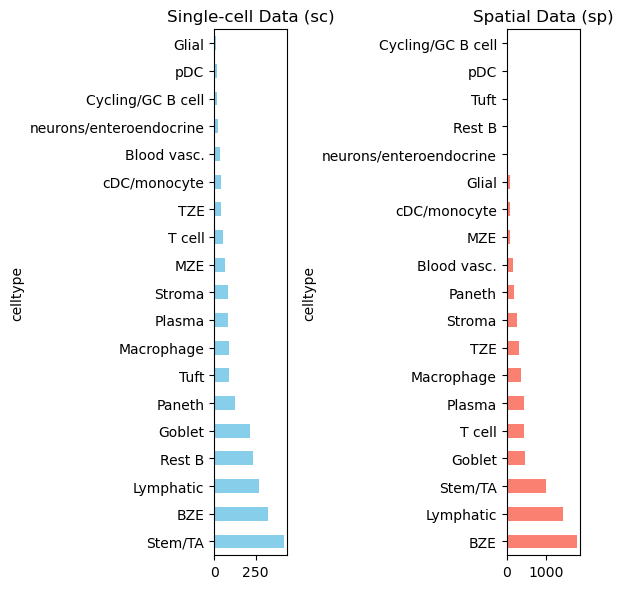

In [187]:
celltypes = np.array(list(set.intersection(set(adata_sp.obs["celltype"]), set(adata_sc.obs["celltype"]))))
fig, axes = plt.subplots(1, 2, figsize=(6, 6))

adata_sc[adata_sc.obs["celltype"].isin(celltypes)].obs["celltype"].value_counts().plot(
    kind="barh", ax=axes[0], color="skyblue"
)
axes[0].set_title("Single-cell Data (sc)")

adata_sp[adata_sp.obs["celltype"].isin(celltypes)].obs["celltype"].value_counts().plot(
    kind="barh", ax=axes[1], color="salmon"
)
axes[1].set_title("Spatial Data (sp)")

plt.tight_layout() 
plt.show()

### Sample from scvi embedding

In [ ]:
sampled_expressions = paired_iterator_sampled_expression(
    10,
    a=(adata_sc, model_sc),
    b=(adata_sp, model_sp)
)

### Regular NMF

#### Generate Data

In [ ]:
bar_values = np.array([
    (lambda adata, W, H, _: pearsonr(adata.X.mean(axis=0), (W @ H).mean(axis=0))[0])(
        *(lambda adata: (adata, *non_negative_factorization(adata.X, n_components=n_components)))(
            (lambda adata, celltype: adata[adata.obs["celltype"] == celltype])(
                adata_sp,
                celltype
            )
        )
    )
    for celltype in celltypes
])

box_values = np.array([
    [
        (lambda adata, W, H, _: pearsonr(adata.X.mean(axis=0), (W @ H).mean(axis=0))[0])(
            *(lambda adata: (adata, *non_negative_factorization(adata.X, n_components=n_components)))(
                (lambda adata, celltype: adata[adata.obs["celltype"] == celltype])(
                    adata,
                    celltype
                )
            )
        )
        for celltype in celltypes
    ]
    for adata in [paired_expression[1] for paired_expression in sampled_expressions]
])

#### Plotting

In [ ]:
sort_cells = np.argsort(np.median(box_values, axis=0))

fig, ax = plt.subplots(figsize=(10, 6))
x_positions = np.arange(len(celltypes)) + 1 

boxprops = dict(facecolor="none", edgecolor="black", linewidth=1.5) 
medianprops = dict(color="black", linewidth=1.5)  
whiskerprops = dict(color="black", linewidth=1) 
capprops = dict(color="black", linewidth=1) 

ax.boxplot(box_values[:, sort_cells], positions=x_positions, 
           patch_artist=True, 
           boxprops=boxprops, medianprops=medianprops, 
           whiskerprops=whiskerprops, capprops=capprops)

ax.bar(x_positions, bar_values[sort_cells], color="skyblue", alpha=0.6, width=0.5, edgecolor="black")

ax.set_xlabel("Cell Types")
ax.set_ylabel("Pearson Correlation")
ax.set_title("Pearson Correlation Distribution Across Cell Types")
ax.set_xticks(x_positions)
ax.set_xticklabels(celltypes[sort_cells], rotation=45, ha="right")
ax.set_ylim(0, 1)

plt.show()

### Preinitialised NMF

#### Generate Data

In [ ]:
bar_values = np.array([(lambda adata, W, H, W_init, H_init: pearsonr(adata[:, shared_genes].X.mean(axis=0), (W @ H).mean(axis=0))[0])(
        *(lambda adata_query, adata_reference, shared_genes_mask_reference, n_components: (adata_query, *nmf_transfer(adata_query, adata_reference, shared_genes_mask_reference, n_components=n_components)))(
            adata_query=adata_sp[adata_sp.obs["celltype"] == celltype],
            adata_reference=adata_sc[adata_sc.obs["celltype"] == celltype],
            shared_genes_mask_reference=shared_genes_mask_sc,
            n_components=n_components
        )
    ) for celltype in celltypes])

box_values = np.array([[(lambda adata, W, H, W_init, H_init: pearsonr(adata[:, shared_genes].X.mean(axis=0), (W @ H).mean(axis=0))[0])(
        *(lambda adata_query, adata_reference, shared_genes_mask_reference, n_components: (adata_query, *nmf_transfer(adata_query, adata_reference, shared_genes_mask_reference, n_components=n_components)))(
            adata_query=adata_query[adata_query.obs["celltype"] == celltype],
            adata_reference=adata_reference[adata_reference.obs["celltype"] == celltype],
            shared_genes_mask_reference=shared_genes_mask_sc,
            n_components=n_components
        )
    ) for celltype in celltypes] for adata_reference, adata_query in sampled_expressions])

#### Plotting

In [ ]:
sort_cells = np.argsort(np.median(box_values, axis=0))

fig, ax = plt.subplots(figsize=(10, 6))
x_positions = (np.arange(len(celltypes)) + 1)

boxprops = dict(facecolor="none", edgecolor="black", linewidth=1)  
medianprops = dict(color="black", linewidth=1)  
whiskerprops = dict(color="black", linewidth=1)  
capprops = dict(color="black", linewidth=1)  

ax.boxplot(box_values[:, sort_cells], positions=x_positions, 
           patch_artist=True, 
           boxprops=boxprops, medianprops=medianprops, 
           whiskerprops=whiskerprops, capprops=capprops)

ax.bar(x_positions, bar_values[sort_cells], color="skyblue", alpha=0.6, width=0.5, edgecolor="black")
ax.set_xlabel("Cell Types")
ax.set_ylabel("Pearson Correlation")
ax.set_title("Pearson Correlation Distribution Across Cell Types")
ax.set_xticks(x_positions)
ax.set_xticklabels(celltypes[sort_cells], rotation=45, ha="right")
ax.set_ylim(0, 1)

plt.show()

In [ ]:
x_values = box_values.mean(axis=0)
y_values_sc = adata_sc.obs["celltype"].value_counts()[celltypes]
y_values_sp = adata_sp.obs["celltype"].value_counts()[celltypes]
r_sc, p_sc = pearsonr(x_values, y_values_sc)
r_sp, p_sp = pearsonr(x_values, y_values_sp)

fig, axes = plt.subplots(1, 2, figsize=(6, 3), sharex=True, sharey=True)

axes[0].scatter(x_values, y_values_sc)
axes[0].set_title(f'adata_sc (r={r_sc:.2f}, p={p_sc:.2g})')
axes[0].set_xlabel("Mean Box Values")
axes[0].set_ylabel("Celltype Count")

axes[1].scatter(x_values, y_values_sp)
axes[1].set_title(f'adata_sp (r={r_sp:.2f}, p={p_sp:.2g})')
axes[1].set_xlabel("Mean Box Values")

plt.tight_layout()
plt.show()

### Preinitialised and masked NMF

#### Generate Data

In [ ]:
np.array([(lambda adata_query, adata_reference, shared_genes_mask_reference, n_components: pearsonr(
    adata_query[:, shared_genes].X.mean(axis=0), 
    np.hstack([
        (lambda W, H, W_init, H_init, gene_filter_mask: W @ H_init[:, ~gene_filter_mask])(
            *(
                lambda adata_query, adata_reference, shared_genes_mask_reference, n_components: 
                nmf_transfer(adata_query, adata_reference, shared_genes_mask_reference, 
                             n_components=n_components, gene_filter_mask=~np.isin(shared_genes, gene)) 
                + (~np.isin(shared_genes, gene),)
            )(adata_query, adata_reference, shared_genes_mask_reference, n_components)
        )
        for gene in shared_genes
    ]).mean(axis=0)
)[0])(
    adata_sp[adata_sp.obs["celltype"] == celltype],
    adata_sc[adata_sc.obs["celltype"] == celltype],
    shared_genes_mask_sc,
    n_components=n_components
) for celltype in ["Stem/TA"]])

In [ ]:
[~np.isin(shared_genes, gene) for gene in shared_genes]

In [ ]:
bar_values = np.array([(lambda adata_query, adata_reference, shared_genes_mask_reference, n_components: pearsonr(
    adata_query[:, shared_genes].X.mean(axis=0), 
    np.hstack([
        (lambda W, H, W_init, H_init, gene_filter_mask: W @ H_init[:, ~gene_filter_mask])(
            *(
                lambda adata_query, adata_reference, shared_genes_mask_reference, n_components: 
                nmf_transfer(adata_query, adata_reference, shared_genes_mask_reference, 
                             n_components=n_components, gene_filter_mask=~np.isin(shared_genes, gene)) 
                + (~np.isin(shared_genes, gene),)
            )(adata_query, adata_reference, shared_genes_mask_reference, n_components)
        )
        for gene in shared_genes
    ]).mean(axis=0)
)[0])(
    adata_sp[adata_sp.obs["celltype"] == celltype],
    adata_sc[adata_sc.obs["celltype"] == celltype],
    shared_genes_mask_sc,
    n_components=n_components
) for celltype in celltypes])

In [ ]:
box_values = np.array([np.array([(lambda adata_query, adata_reference, shared_genes_mask_reference, n_components: pearsonr(
    adata_query[:, shared_genes].X.mean(axis=0), 
    np.hstack([
        (lambda W, H, W_init, H_init, gene_filter_mask: W @ H_init[:, ~gene_filter_mask])(
            *(
                lambda adata_query, adata_reference, shared_genes_mask_reference, n_components: 
                nmf_transfer(adata_query, adata_reference, shared_genes_mask_reference, 
                             n_components=n_components, gene_filter_mask=~np.isin(shared_genes, gene)) 
                + (~np.isin(shared_genes, gene),)
            )(adata_query, adata_reference, shared_genes_mask_reference, n_components)
        )
        for gene in shared_genes
    ]).mean(axis=0)
)[0])(
    adata_query[adata_query.obs["celltype"] == celltype],
    adata_reference[adata_reference.obs["celltype"] == celltype],
    shared_genes_mask_sc,
    n_components=n_components
) for celltype in celltypes]) for adata_reference, adata_query in sampled_expressions])

#### plotting

In [ ]:
sort_cells = np.argsort(np.median(box_values, axis=0))

fig, ax = plt.subplots(figsize=(10, 6))
x_positions = (np.arange(len(celltypes)) + 1)

boxprops = dict(facecolor="none", edgecolor="black", linewidth=1)  
medianprops = dict(color="black", linewidth=1)  
whiskerprops = dict(color="black", linewidth=1)  
capprops = dict(color="black", linewidth=1)  

ax.boxplot(box_values[:, sort_cells], positions=x_positions, 
           patch_artist=True, 
           boxprops=boxprops, medianprops=medianprops, 
           whiskerprops=whiskerprops, capprops=capprops)

ax.bar(x_positions, bar_values[sort_cells], color="skyblue", alpha=0.6, width=0.5, edgecolor="black")
ax.set_xlabel("Cell Types")
ax.set_ylabel("Pearson Correlation")
ax.set_title("Pearson Correlation Distribution Across Cell Types")
ax.set_xticks(x_positions)
ax.set_xticklabels(celltypes[sort_cells], rotation=45, ha="right")
ax.set_ylim(0, 1)

plt.show()

In [ ]:
x_values = box_values.mean(axis=0)
y_values_sc = adata_sc.obs["celltype"].value_counts()[celltypes]
y_values_sp = adata_sp.obs["celltype"].value_counts()[celltypes]
r_sc, p_sc = pearsonr(x_values, y_values_sc)
r_sp, p_sp = pearsonr(x_values, y_values_sp)

fig, axes = plt.subplots(1, 2, figsize=(6, 3), sharex=True, sharey=True)

axes[0].scatter(x_values, y_values_sc)
axes[0].set_title(f'adata_sc (r={r_sc:.2f}, p={p_sc:.2g})')
axes[0].set_xlabel("Mean Box Values")
axes[0].set_ylabel("Celltype Count")

axes[1].scatter(x_values, y_values_sp)
axes[1].set_title(f'adata_sp (r={r_sp:.2f}, p={p_sp:.2g})')
axes[1].set_xlabel("Mean Box Values")

plt.tight_layout()
plt.show()

In [ ]:
gene = shared_genes[0]
test = (*nmf_transfer(adata_sp[adata_sp.obs["celltype"] == "Stem/TA"], adata_sc[adata_sc.obs["celltype"] == "Stem/TA"], shared_genes_mask_sc, ~np.isin(shared_genes, gene)), np.isin(shared_genes, gene))

In [ ]:
(lambda f, params_1, params_2: f())

In [29]:
f = lambda a, b: (a, b,1,2,3)

In [44]:
res = non_negative_factorization(adata_sc[:, shared_genes_mask_sc].X, n_components=2)

In [53]:
res_2 = non_negative_factorization(adata_sp[:, shared_genes].X, H=res[1], init="custom", update_H=False)

In [55]:
(res_2[0] @ res[1])

(7416, 203)

In [57]:
(
    lambda nmf1, nmf2: lambda adata_sc, adata_sp, shared_genes_mask_sc, shared_genes, n_components: 
        nmf2(adata_sp[:, shared_genes].X, nmf1(adata_sc[:, shared_genes_mask_sc].X, n_components)[1])
)(

)

<function __main__.<lambda>(nmf1, nmf2)>

In [198]:
nmf_recon = (
    lambda nmf1, nmf2: lambda adata_query, adata_reference, shared_genes_mask_reference, shared_genes, n_components: 
        np.hstack([nmf2(
            adata_query[:, shared_genes].X, 
            nmf1(adata_reference[:, shared_genes_mask_reference].X, n_components)[1],
            gene_mask
        ) for gene_mask in  np.array([~np.isin(shared_genes, gene) for gene in shared_genes])])
)(
    lambda X, n_components: non_negative_factorization(X, n_components=n_components), 
    lambda X, H_init, gene_mask: non_negative_factorization(X[:, gene_mask], H=H_init[:, gene_mask], init="custom", update_H=False)[0] @ H_init[:, ~gene_mask]
)
test = pd.DataFrame([
    (
    celltype,
    n_components,
    pearsonr(
        adata_sp[adata_sp.obs["celltype"] == celltype][:, shared_genes].X.mean(axis=0),
        nmf_recon(adata_sp[adata_sp.obs["celltype"] == celltype], adata_sc[adata_sc.obs["celltype"] == celltype], shared_genes_mask_sc, shared_genes, n_components).mean(axis=0)
    )[0]
    )
for celltype, n_components in itertools.product(celltypes, [3,4,5,6,7,8])])
test


/home/gruengroup/christian/mamba_envs/scvi_cuda-env/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/gruengroup/christian/mamba_envs/scvi_cuda-env/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/gruengroup/christian/mamba_envs/scvi_cuda-env/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/gruengroup/christian/mamba_envs/scvi_cuda-env/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/gruengroup/christian/mamba_envs/scvi_cuda-env/lib/python3.10/site-

,0,1,2
0,cDC/monocyte,3,0.781663
1,cDC/monocyte,4,0.785072
2,cDC/monocyte,5,0.780095
3,cDC/monocyte,6,0.780270
4,cDC/monocyte,7,0.773396
...,...,...,...
109,Lymphatic,4,0.177068
110,Lymphatic,5,0.180263
111,Lymphatic,6,0.174986
112,Lymphatic,7,0.174795


In [254]:
[bootstrap_adata(adata_sp) for _ in range(2)]

[View of AnnData object with n_obs × n_vars = 7416 × 241
     obs: 'umi_sct', 'log_umi_sct', 'gene_sct', 'log_gene_sct', 'umi_per_gene_sct', 'log_umi_per_gene_sct', 'leiden0.4', 'leiden0.5', 'nico_ct', 'celltype', '_scvi_batch', '_scvi_labels'
     var: 'n_counts'
     uns: '_scvi_uuid', '_scvi_manager_uuid',
 View of AnnData object with n_obs × n_vars = 7416 × 241
     obs: 'umi_sct', 'log_umi_sct', 'gene_sct', 'log_gene_sct', 'umi_per_gene_sct', 'log_umi_per_gene_sct', 'leiden0.4', 'leiden0.5', 'nico_ct', 'celltype', '_scvi_batch', '_scvi_labels'
     var: 'n_counts'
     uns: '_scvi_uuid', '_scvi_manager_uuid']

In [266]:
lambda adata_query, adata_reference, n: itertools.starmap(
    (lambda f: lambda a, b: (f(a), f(b)))(lambda adata: adata[np.random.choice(adata.n_obs, adata.n_obs)]), 
    [(adata_query, adata_reference)] * n
)


<function __main__.<lambda>(adata_query, adata_reference, n)>

In [277]:
np.stack([nmf_transfer_2(adata_query, adata_reference, shared_genes_mask_sc, shared_genes, n_components=3)[0] for adata_query, adata_reference in bootstrap_adatas(adata_sp[adata_sp.obs["celltype"] == "Stem/TA"], adata_sc[adata_sc.obs["celltype"] == "Stem/TA"], 2)])

/home/gruengroup/christian/mamba_envs/scvi_cuda-env/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/gruengroup/christian/mamba_envs/scvi_cuda-env/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


(2, 997, 3)

In [292]:
# This function should only return the W matrix of the second NMF for the purpose of repeatedly running it on bootstrapped data and correlating the W matrices with eachother
nmf_transfer_2= (
    lambda nmf1, nmf2: lambda adata_query, adata_reference, shared_genes_mask_reference, shared_genes, n_components: 
        nmf2(
            adata_query[:, shared_genes].X, 
            nmf1(adata_reference[:, shared_genes_mask_reference].X, n_components)[1],
        )
)(
    lambda X, n_components: non_negative_factorization(X, n_components=n_components), 
    lambda X, H_init: non_negative_factorization(X, H=H_init, init="custom", update_H=False)
)

bootstrap_adatas = (
    lambda adata_query, adata_reference, n: itertools.starmap(
        (lambda f: lambda a, b: (f(a), f(b)))(lambda adata: adata[np.random.choice(adata.n_obs, adata.n_obs)]), 
        [(adata_query, adata_reference)] * n
    )
)

bootstrap_nmf_Ws = (
    lambda adata_query, adata_reference, n: np.stack(
        [nmf_transfer_2(adata_query, adata_reference, shared_genes_mask_sc, shared_genes, n_components=3)[0] 
         for adata_query, adata_reference in bootstrap_adatas(adata_query, adata_reference, n)]
    )
)

(lambda f, g: lambda adata_query, adata_reference, n: f(g(adata_query, adata_reference, n)))(
    align_factors_3d,
    bootstrap_nmf_Ws
)(
    adata_sp[adata_sp.obs["celltype"] == "Stem/TA"],
    adata_sc[adata_sc.obs["celltype"] == "Stem/TA"],
    5
)


/home/gruengroup/christian/mamba_envs/scvi_cuda-env/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/gruengroup/christian/mamba_envs/scvi_cuda-env/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/gruengroup/christian/mamba_envs/scvi_cuda-env/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/gruengroup/christian/mamba_envs/scvi_cuda-env/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


array([[[0.14093809, 0.4342851 , 0.063488  ],
        [0.24210377, 0.49926153, 0.        ],
        [0.08572519, 0.2119578 , 0.        ],
        ...,
        [0.08180138, 0.680003  , 0.02446663],
        [0.02231053, 0.09839235, 0.00629343],
        [0.05160508, 0.7691976 , 0.09321822]],

       [[0.1748978 , 0.        , 0.        ],
        [0.0571846 , 0.02026077, 0.        ],
        [0.27806795, 0.00325805, 0.        ],
        ...,
        [0.03461521, 0.00424778, 0.        ],
        [1.5700878 , 0.13598044, 0.1288483 ],
        [1.1517252 , 0.12023416, 0.12075972]],

       [[0.10046469, 1.4842381 , 0.        ],
        [0.36832148, 1.6564339 , 0.        ],
        [0.28172314, 0.49239758, 0.0199106 ],
        ...,
        [0.19495662, 0.25813404, 0.0231671 ],
        [0.13786417, 1.561082  , 0.06068866],
        [0.02808399, 0.12346524, 0.        ]],

       [[0.8162226 , 0.03860565, 0.2150431 ],
        [0.49446926, 0.15659226, 0.00728013],
        [0.18867986, 0.02199575, 0.

In [287]:
import numpy as np
from scipy.optimize import linear_sum_assignment
from sklearn.metrics.pairwise import cosine_distances
def align_factors_3d(W_array, axis=0):
    """
    Aligns factors along a specified axis using the Hungarian algorithm.
    
    Parameters:
    W_array: ndarray of shape (num_runs, n_samples, n_components).
    axis: Axis along which to align factors (default: 0 for multiple runs of NMF).

    Returns:
    Aligned W_array of the same shape.
    """
    if axis != 0:
        raise NotImplementedError("Only axis=0 is currently supported.")

    num_runs, n_samples, n_components = W_array.shape
    reference_W = W_array[0]  # Use the first W as reference
    aligned_W_array = np.empty_like(W_array)
    aligned_W_array[0] = reference_W  # Keep the first as is

    for i in range(1, num_runs):
        W = W_array[i]

        # Compute cost matrix (cosine distances between factors)
        cost_matrix = cosine_distances(reference_W.T, W.T)  # (n_components, n_components)
        row_ind, col_ind = linear_sum_assignment(cost_matrix)

        # Reorder the components based on the Hungarian algorithm
        aligned_W_array[i] = W[:, col_ind]  # Align components

    return aligned_W_array

In [232]:
adata_sc.n_obs

2239

In [238]:
bootstrap_adata = (lambda adata: adata[np.random.choice(adata.n_obs, adata.n_obs)])

View of AnnData object with n_obs × n_vars = 2239 × 21197
    obs: 'cluster', 'celltype', '_scvi_batch', '_scvi_labels'
    var: 'n_counts'
    uns: '_scvi_uuid', '_scvi_manager_uuid'

In [233]:
np.random.choice(20, 20)

array([ 2,  2, 19,  9,  4,  1, 17, 17, 16,  6,  6, 14,  7, 13, 11, 17,  0,
       17, 12, 17])

In [227]:
(lambda f, g: lambda adata, recon: f(g(adata), g(recon)))(
    pearsonr,
    functools.partial(np.mean, axis=0)
)(
    adata_sp[adata_sp.obs["celltype"] == "Stem/TA"][:, shared_genes].X,
    nmf_recon(adata_sp[adata_sp.obs["celltype"] == "Stem/TA"], adata_sc[adata_sc.obs["celltype"] == "Stem/TA"], shared_genes_mask_sc, shared_genes, n_components=3)
)

/home/gruengroup/christian/mamba_envs/scvi_cuda-env/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/gruengroup/christian/mamba_envs/scvi_cuda-env/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/gruengroup/christian/mamba_envs/scvi_cuda-env/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/gruengroup/christian/mamba_envs/scvi_cuda-env/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/gruengroup/christian/mamba_envs/scvi_cuda-env/lib/python3.10/site-

PearsonRResult(statistic=np.float32(0.41653454), pvalue=np.float64(6.358367656856994e-10))

<Axes: xlabel='0'>

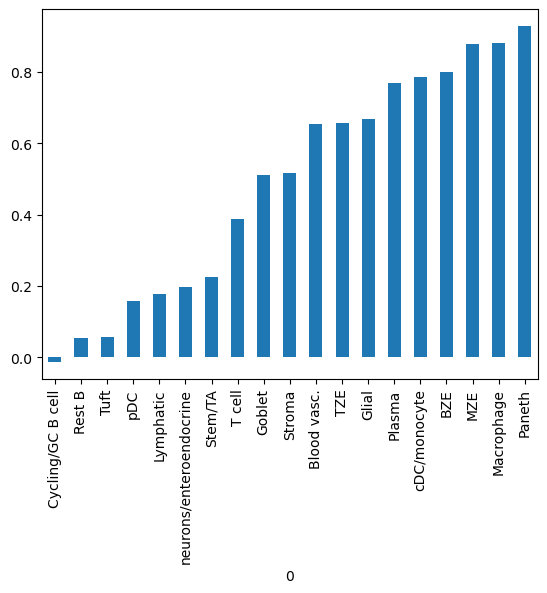

In [221]:

test.pivot(index=0, columns=1, values=2)[4].sort_values(ascending=True).plot(kind="bar")

<Axes: xlabel='1'>

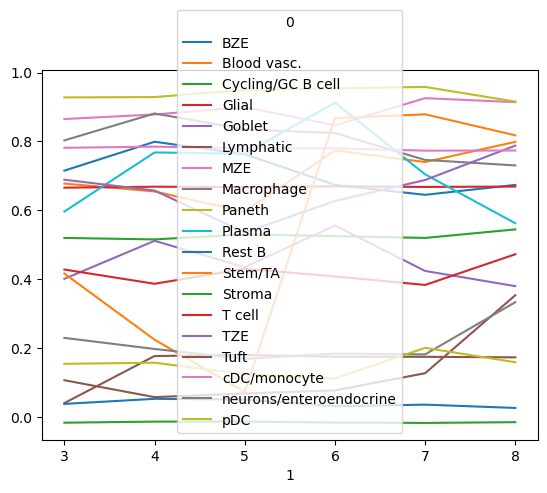

In [207]:
test.pivot(index=0, columns=1, values=2).T.plot()

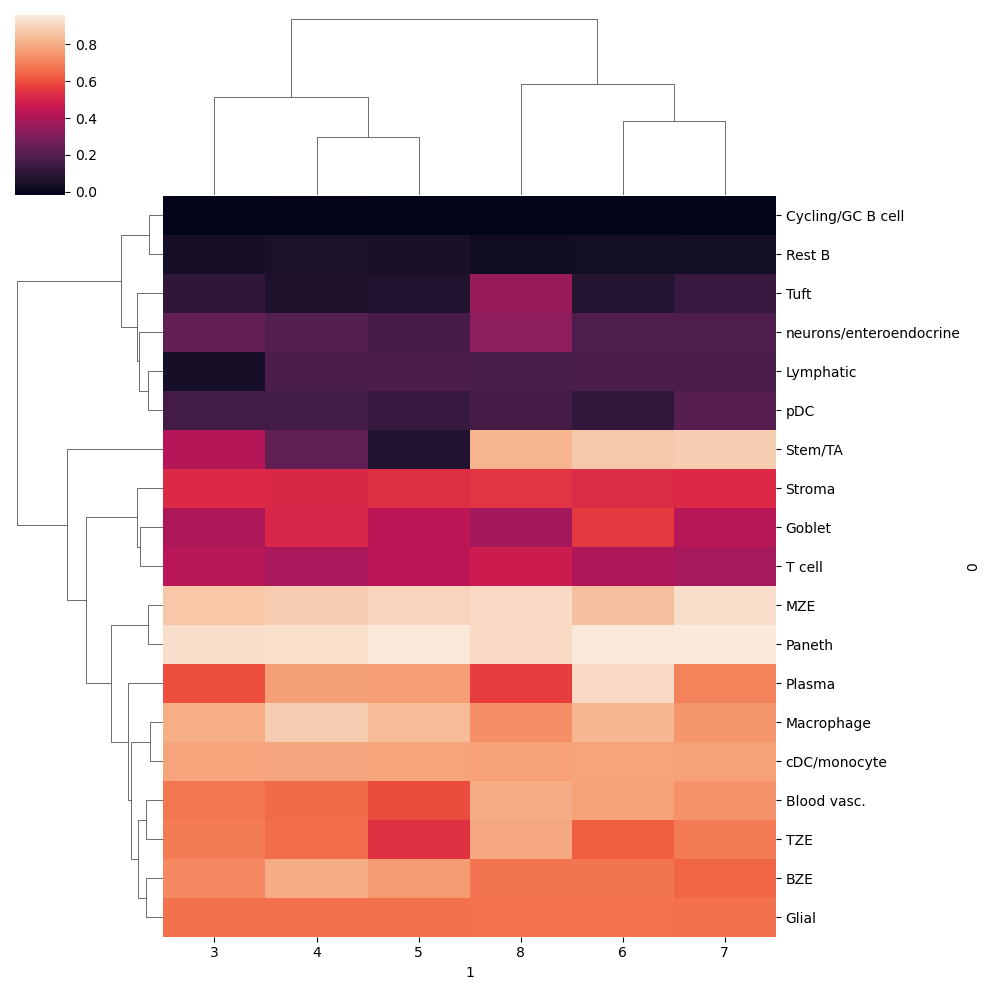

In [200]:
sns.clustermap(test.pivot(index=0, columns=1, values=2))

In [164]:
nmf_transfer_2 = (
    lambda nmf1, nmf2: lambda adata_query, adata_reference, shared_genes_mask_reference, shared_genes, n_components, gene_mask: 
        nmf2(
            adata_query[:, shared_genes].X, 
            nmf1(adata_reference[:, shared_genes_mask_reference].X, n_components)[1],
            gene_mask
        )
)(
    lambda X, n_components: non_negative_factorization(X, n_components=n_components), 
    lambda X, H_init, gene_mask: non_negative_factorization(X[:, gene_mask], H=H_init[:, gene_mask], init="custom", update_H=False)[0] @ H_init[:, ~gene_mask]
)
[nmf_transfer_2]
nmf_transfer_2 = functools.partial(
    nmf_transfer_2,
    adata_query=adata_sp[adata_sp.obs["celltype"] == "Stem/TA"], 
    adata_reference=adata_sc[adata_sc.obs["celltype"] == "Stem/TA"], 
    shared_genes_mask_reference=shared_genes_mask_sc, 
    shared_genes=shared_genes, 
    n_components=8,
)

In [183]:
res.shape

(997, 203)

In [149]:
np.eye(len(shared_genes), dtype=bool)

array([[ True, False, False, ..., False, False, False],
       [False,  True, False, ..., False, False, False],
       [False, False,  True, ..., False, False, False],
       ...,
       [False, False, False, ...,  True, False, False],
       [False, False, False, ..., False,  True, False],
       [False, False, False, ..., False, False,  True]])

In [37]:
(lambda f, params_1: lambda g, params_2: g(params_2, f(params_1)[0]))(functools.partial(f, 1), 2)(f, 3)

TypeError: <lambda>() takes 0 positional arguments but 2 were given

In [42]:
(lambda adata_reference, shared_genes_mask_reference, n_components: lambda adata_query, shared_genes: non_negative_factorization(adata_reference[:, shared_genes_mask_reference].X.toarray(), n_components=n_components))(adata_sc, shared_genes_mask_sc, n_components=2)(
    adata_sp,
    shared_genes
)

(array([[8.6556540e+00, 6.6448145e-02],
        [1.8693806e+01, 2.6218980e-03],
        [5.0631031e+01, 0.0000000e+00],
        ...,
        [7.8651610e-05, 4.1575222e-03],
        [0.0000000e+00, 9.8176517e-02],
        [7.1884156e-06, 1.6825758e-03]], dtype=float32),
 array([[9.58759396e-04, 4.72621759e-04, 1.85721107e-02, 1.01885892e-01,
         5.32420290e-06, 1.00281630e-02, 0.00000000e+00, 0.00000000e+00,
         3.73115597e-07, 5.72337257e-03, 6.46889339e-06, 4.97659552e-04,
         8.22866332e-06, 1.26944433e-05, 8.60000582e-05, 0.00000000e+00,
         9.82169647e+01, 5.12335682e-04, 1.86657086e-02, 6.71017333e-04,
         9.12472373e-04, 1.27846576e-07, 1.82993300e-02, 1.79817167e-03,
         5.67183406e-07, 1.38482142e-06, 9.42293741e-03, 1.25924464e-06,
         7.44349975e-03, 3.68846506e-01, 0.00000000e+00, 5.33315004e-04,
         1.72031496e-03, 1.71145320e-01, 1.02317915e-03, 1.33387775e-05,
         0.00000000e+00, 2.22905743e-04, 2.35257782e-02, 5.12113683e-02,


In [28]:
(lambda nmf_func, adata_reference, shared_genes_mask_reference, n_components: 
    lambda adata_query, shared_genes: nmf_func(adata_reference[:, shared_genes_mask_reference].X.toarray(), n_components=n_components)[1])(
        nmf_func=non_negative_factorization,
        adata_reference=adata_sc,
        shared_genes_mask_reference=shared_genes_mask_sc,
        n_components=2
    )(
        adata_query=adata_sp,
        shared_genes=shared_genes
    )

array([[9.58759221e-04, 4.72621789e-04, 1.85721125e-02, 1.01885960e-01,
        5.32420381e-06, 1.00281630e-02, 0.00000000e+00, 0.00000000e+00,
        3.73115597e-07, 5.72337303e-03, 6.46889930e-06, 4.97659552e-04,
        8.22866605e-06, 1.26944724e-05, 8.60000873e-05, 0.00000000e+00,
        9.82169647e+01, 5.12335740e-04, 1.86657105e-02, 6.71017391e-04,
        9.12472373e-04, 1.27846775e-07, 1.82993319e-02, 1.79817167e-03,
        5.67183577e-07, 1.38482164e-06, 9.42293834e-03, 1.25924498e-06,
        7.44350022e-03, 3.68846506e-01, 0.00000000e+00, 5.33315062e-04,
        1.72031508e-03, 1.71145350e-01, 1.02317915e-03, 1.33387775e-05,
        0.00000000e+00, 2.22905743e-04, 2.35257782e-02, 5.12113683e-02,
        7.58006945e-02, 6.02897257e-03, 3.38682812e-03, 9.49590355e-02,
        1.30761496e-03, 5.71161509e-03, 6.27180189e-02, 0.00000000e+00,
        1.41547978e-01, 5.68239763e-03, 0.00000000e+00, 9.57579119e-04,
        1.10298045e-01, 2.33750865e-02, 4.12381813e-03, 1.250869

In [19]:
(lambda nmf_res: lambda a: )(non_negative_factorization(adata_sp[:, shared_genes].X, n_components=2))

array([[0.02986195, 0.06067729],
       [0.        , 0.24758457],
       [0.00053764, 0.33388898],
       ...,
       [0.00124292, 0.01722305],
       [0.04963792, 0.02620527],
       [0.        , 0.12982737]], dtype=float32)

In [ ]:
product

In [ ]:
pd.DataFrame([(a, b, a * b) for a, b in itertools.product([1, 2, 3], [10, 20, 30])])

In [ ]:
pd.DataFrame({(a, b): a * b for a, b in product})

In [ ]:
a = range(0, 3)
b = range(0, 3)
product = list(itertools.product(a, b))
results = [a * b for a, b in product]
pd.DataFrame(product, results)

In [ ]:
test = []
for gene_mask in [~np.isin(shared_genes, gene) for gene in shared_genes]:
    W, H, W_init, H_init = nmf_transfer(adata_sp[adata_sp.obs["celltype"] == "Stem/TA"], adata_sc[adata_sc.obs["celltype"] == "Stem/TA"], shared_genes_mask_sc, gene_filter_mask=gene_mask, n_components=8)
    test.append(W @ H_init[:, ~gene_mask])

In [ ]:
pearsonr(
    adata_sp[adata_sp.obs["celltype"] == "Stem/TA"][:, shared_genes].X.mean(axis=0),
    np.hstack(test).mean(axis=0)
)

In [ ]:
(lambda f: lambda g: lambda a, b: f(g(a), g(b)))(pearsonr)(functools.partial(np.mean, axis=0))(
    adata_sp[adata_sp.obs["celltype"] == "Stem/TA"][:, shared_genes].X,
    np.hstack(test)
)

In [ ]:
(lambda f, g: lambda a, b: f(g(a), g(b)))(pearsonr, functools.partial(np.mean, axis=0))(
    adata_sp[adata_sp.obs["celltype"] == "Stem/TA"][:, shared_genes].X,
    np.hstack(test)
)

In [ ]:
(lambda f: lambda a, b: (f(a), f(b)))(functools.partial(np.mean, axis=0))(

)

In [ ]:
np.hstack(test).shape

In [ ]:
(lambda f: lambda g: lambda a, b: (f(a), g(b)))(lambda adata: adata[:, shared_genes].X.toarray())

In [ ]:
(lambda f, g: lambda a, b: f(g(a), g(b)))(
    pearsonr, 
    functools.partial(np.mean, axis=0),
)(lambda f, g: lambda a: (f(a), g(a)))(
   # lambda adata: adata[:, shared_genes].X.toarray(),
)

In [ ]:
(
    lambda adata_query, adata_reference, shared_genes_mask_reference, n_components, shared_genes, celltype: 
                pearsonr(
                    np.mean(
                        adata_query[:, shared_genes].X.toarray(), 
                        axis=0
                    ),
                    np.mean(
                        np.hstack(
                            [
                                (lambda W, H, W_init, H_init, arg: W @ H_init[:, ~arg])(
                                    *(lambda func, arg: (*func(arg), arg))(
                                        functools.partial(
                                            nmf_transfer, 
                                            adata_query[adata_query.obs["celltype"] == celltype], 
                                            adata_reference[adata_reference.obs["celltype"] == celltype], 
                                            shared_genes_mask_reference, 
                                            n_components=n_components), 
                                        ~np.isin(shared_genes, gene)
                                    )
                                )
                                for gene in shared_genes
                            ]
                        ),
                        axis=0
                    )
                )
)(
    adata_sp,
    adata_sc,
    shared_genes_mask_sc,
    n_components=8,
    shared_genes=shared_genes,
    celltype="Stem/TA",
)

In [ ]:
df = (
    lambda adata_query, adata_reference, shared_genes_mask_reference, n_components_range, shared_genes, celltypes: pd.DataFrame(
        [
            (
                celltype,
                n_components, 
                pearsonr(
                    np.mean(
                        adata_query[:, shared_genes].X, 
                        axis=0
                    ),
                    np.mean(
                        np.hstack(
                            [
                                (lambda W, H, W_init, H_init, arg: W @ H_init[:, ~arg])(
                                    *(lambda func, arg: (*func(arg), arg))(
                                        functools.partial(
                                            nmf_transfer, 
                                            adata_query[adata_query.obs["celltype"] == celltype], 
                                            adata_reference[adata_reference.obs["celltype"] == celltype], 
                                            shared_genes_mask_reference, 
                                            n_components=n_components), 
                                        ~np.isin(shared_genes, gene)
                                    )
                                )
                                for gene in shared_genes
                            ]
                        ),
                        axis=0
                    )
                )[0]
            )
        for celltype, n_components in itertools.product(celltypes, n_components_range)]
    )
)(
    adata_sp,
    adata_sc,
    shared_genes_mask_sc,
    n_components_range=[2, 3, 4, 6, 8],
    shared_genes=shared_genes,
    celltypes=celltypes,
)
df

In [ ]:
df

In [ ]:
sns.heatmap(df.pivot(index=0, columns=1, values=2))

In [ ]:
np.array([(lambda W, H, W_init, H_init, gene_filter_mask: W @ H_init[:, ~gene_filter_mask])(
    *(
        (
            lambda adata_query, adata_reference, shared_genes_mask_reference, gene_filter_mask, celltype, n_components: (
                *nmf_transfer(
                    adata_query[adata_query.obs["celltype"] == celltype], 
                    adata_reference[adata_reference.obs["celltype"] == celltype], 
                    shared_genes_mask_reference, 
                    gene_filter_mask
                ),
                gene_filter_mask
            )
        )(
            adata_sp,
            adata_sc,
            shared_genes_mask_sc,
            ~np.isin(shared_genes, gene),
            "Stem/TA",
            3,
        )
    )
) for gene in [shared_genes[0:2]]])

In [ ]:
[lambda: (*nmf_transfer(adata_sp[adata_sp.obs["celltype"] == "Stem/TA"], adata_sc[adata_sc.obs["celltype"] == "Stem/TA"], shared_genes_mask_sc, ~np.isin(shared_genes, gene)), np.isin(shared_genes, gene)) for gene in shared_genes]

In [ ]:
sort_cells = np.argsort(bar_values)

fig, ax = plt.subplots(figsize=(10, 6))
x_positions = (np.arange(len(celltypes)) + 1)



ax.bar(x_positions, bar_values[sort_cells], color="skyblue", alpha=0.6, width=0.5, edgecolor="black")
ax.set_xlabel("Cell Types")
ax.set_ylabel("Pearson Correlation")
ax.set_title("Pearson Correlation Distribution Across Cell Types")
ax.set_xticks(x_positions)
ax.set_xticklabels(celltypes[sort_cells], rotation=45, ha="right")
ax.set_ylim(0, 1)

plt.show()